# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset: Red Chili Pepper Pests Dataset**

- **Sumber:** Kaggle (https://www.kaggle.com/datasets/indraagustian/red-chili-pepper-pests-dataset)
- **Jenis:** Image Classification (Unstructured Data)
- **Jumlah Kelas:** 4 kelas hama cabai merah:
  - MP (kutu daun/aphid) - Class 0
  - BT (kutu kebul/whitefly) - Class 1
  - T (thrips) - Class 2
  - C (ulat/caterpillar) - Class 3
- **Format:** Gambar JPEG dengan label YOLO-style (.txt files)
- **Identifikasi kelas:** Berdasarkan prefix filename (kutu-daun, kutu-kebul, thrips, ulat)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [20]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

print('Libraries imported successfully')


Libraries imported successfully


# **3. Memuat Dataset**

In [21]:
DATASET_DIR = "/home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset"
IMAGE_SIZE = (224, 224)
CLASS_NAMES = ['MP (kutu daun)', 'BT (kutu kebul)', 'T (thrips)', 'C (ulat)']
CLASS_MAP = {'kutu-daun': 0, 'kutu-kebul': 1, 'thrips': 2, 'thrips-baru': 2, 'ulat': 3}

def get_class(filename):
    prefix = os.path.basename(filename).split('--')[0].lower()
    if prefix in CLASS_MAP:
        return CLASS_MAP[prefix]
    
    label_path = filename.rsplit('.', 1)[0] + '.txt'
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                return int(first_line.split()[0])
                
    raise ValueError(f'Cannot determine class for: {filename}')

def collect_images_and_labels(image_dir):
    image_files = []
    for ext in ('*.jpg', '*.JPG', '*.jpeg', '*.png'):
        image_files.extend(glob.glob(os.path.join(image_dir, ext)))
    
    image_files = sorted(image_files)
    
    if not image_files:
        print(f"Directory empty or not found: {image_dir}")
        return [], []

    labels, valid_files = [], []
    for img_path in image_files:
        try:
            label = get_class(img_path)
            labels.append(label)
            valid_files.append(img_path)
        except ValueError as e:
            print(e)
            
    return valid_files, labels

train_files, train_labels = collect_images_and_labels(os.path.join(DATASET_DIR, 'train', 'images'))
val_files_1, val_labels_1 = collect_images_and_labels(os.path.join(DATASET_DIR, 'val', 'images'))
val_files_2, val_labels_2 = collect_images_and_labels(os.path.join(DATASET_DIR, 'val', 'valid', 'images'))
val_files = val_files_1 + val_files_2
val_labels = val_labels_1 + val_labels_2
test_files, test_labels = collect_images_and_labels(os.path.join(DATASET_DIR, 'test', 'images'))

print(f'Training: {len(train_files)} images')
print(f'Validation: {len(val_files)} images')
print(f'Test: {len(test_files)} images')

Cannot determine class for: /home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset/train/images/IMG_20211201_100935_jpg.rf.3f0be597263fe7912269fa2a3c5a0864.jpg
Cannot determine class for: /home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset/train/images/IMG_20211201_100935_jpg.rf.915935720b7337fb0e2983ae2e2fef36.jpg
Cannot determine class for: /home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset/train/images/IMG_20211201_100935_jpg.rf.de198104ff310a2f808780d9a1c972a5.jpg
Cannot determine class for: /home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset/train/images/IMG_20211201_101052_jpg.rf.10764a17e9959b390cd2cfdef7091939.jpg
Cannot determine class for: /home/kazu/Programming/OpenSource/red-chili-pepper-pests/datasets/RedChiliPepperPestsDataset/train/images/IMG_20211201_101052_jpg.rf.5dbaa210295f764bebf7f495e217fab4.jpg
Cannot det

Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Distribusi data:

# **4. Exploratory Data Analysis (EDA)**

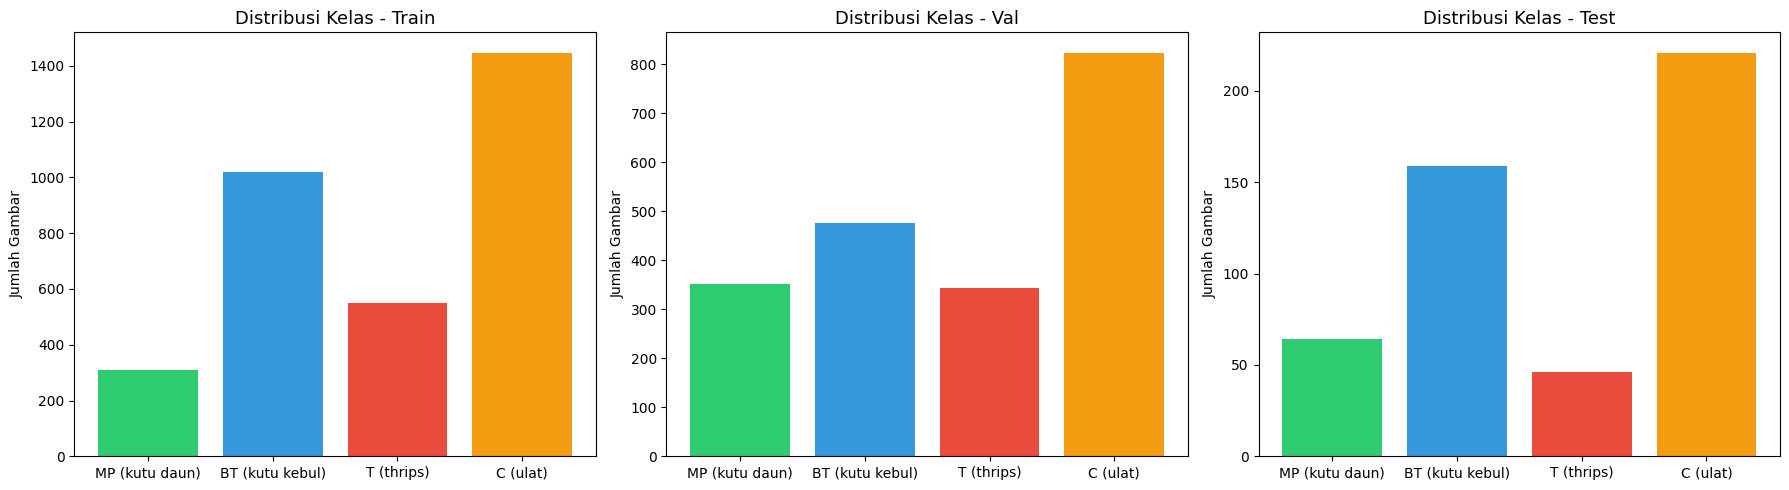

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, labels) in zip(axes, [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]):
    unique, counts = np.unique(labels, return_counts=True)
    ax.bar([CLASS_NAMES[i] for i in unique], counts, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
    ax.set_title(f'Distribusi Kelas - {name}', fontsize=13)
    ax.set_ylabel('Jumlah Gambar')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


Dari distribusi kelas di atas, dapat dilihat bahwa dataset memiliki 4 kelas hama dengan distribusi yang relatif seimbang.

Berikut adalah contoh gambar dari setiap kelas:

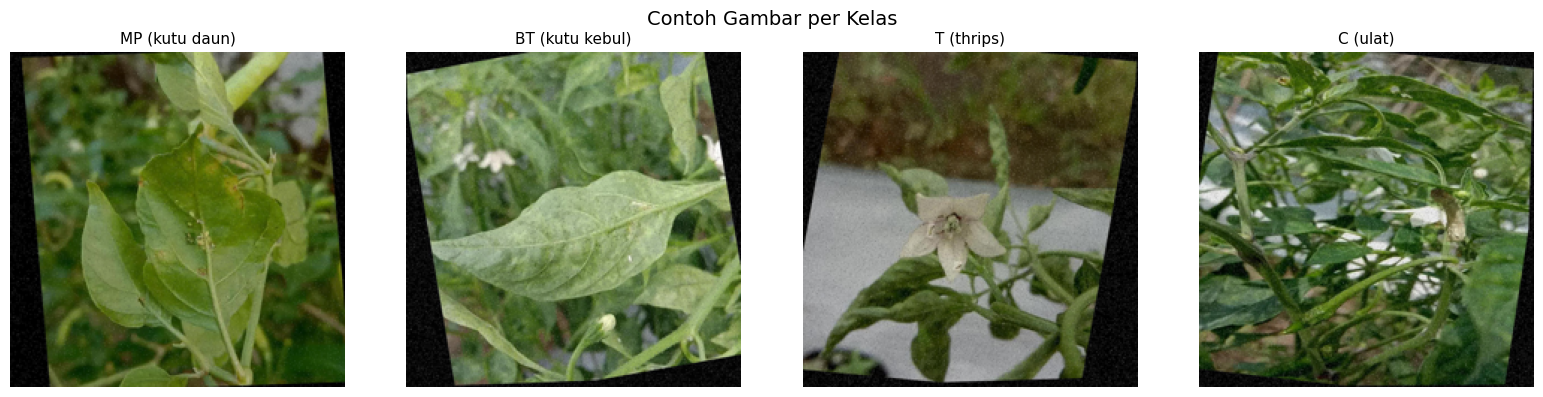

In [23]:
sample_per_class = {}

for f, l in zip(train_files, train_labels):
    if l not in sample_per_class:
        sample_per_class[l] = f
    if len(sample_per_class) == 4:
        break

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx in sorted(sample_per_class.keys()):
    img = Image.open(sample_per_class[idx]).convert('RGB')
    img = img.resize(IMAGE_SIZE)
    axes[idx].imshow(img)
    axes[idx].set_title(CLASS_NAMES[idx], fontsize=11)
    axes[idx].axis('off')

plt.suptitle('Contoh Gambar per Kelas', fontsize=14)
plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
total = len(train_files) + len(val_files) + len(test_files)
print(f'Total gambar: {total}')
print(f'  Train: {len(train_files)} ({len(train_files)/total*100:.1f}%)')
print(f'  Val:   {len(val_files)} ({len(val_files)/total*100:.1f}%)')
print(f'  Test:  {len(test_files)} ({len(test_files)/total*100:.1f}%)')


Total gambar: 5811
  Train: 3325 (57.2%)
  Val:   1996 (34.3%)
  Test:  490 (8.4%)


# **5. Data Preprocessing**

In [25]:
all_train_files = train_files + val_files
all_train_labels = train_labels + val_labels
train_files_final, val_files_final, train_labels_final, val_labels_final = train_test_split(
    all_train_files, all_train_labels, test_size=0.15, random_state=42
)

print(f'Final split:')
print(f'  Train : {len(train_files_final)} gambar')
print(f'  Val   : {len(val_files_final)} gambar')
print(f'  Test  : {len(test_files)} gambar')


Final split:
  Train : 4522 gambar
  Val   : 799 gambar
  Test  : 490 gambar


In [26]:
np.save('train_files.npy', np.array(train_files_final, dtype=object))
np.save('train_labels.npy', np.array(train_labels_final))
np.save('val_files.npy', np.array(val_files_final, dtype=object))
np.save('val_labels.npy', np.array(val_labels_final))
np.save('test_files.npy', np.array(test_files, dtype=object))
np.save('test_labels.npy', np.array(test_labels))

print('Preprocessed data saved successfully!')


Preprocessed data saved successfully!
